# <center>EDA_on_Shark_Tank_India_Dataset</center>

### Problem Statement

Shark Tank India features aspiring entrepreneurs pitching their business ideas to a panel of investors (sharks), seeking funding in exchange for equity. While the show is popular and entertaining, it also presents a rich dataset for investment analysis and business decision-making.

The challenge is to analyze the investment patterns, deal structures, and investor participation using data from Shark Tank India Season 1, in order to gain insights into which types of ideas get funded, what kind of deals are common, and how individual sharks behave in investment scenarios.

### Objective

The objective of this case study is to:
- Analyze the investment trends and decision-making behavior of the sharks.
- Understand what types of business ideas are more likely to receive funding.
- Evaluate differences in equity demands and final deal outcomes.
- Examine the presence and participation of different sharks across episodes.
- Gain practical insights into startup funding dynamics from real-world scenarios.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Data Cleaning

In [2]:
#Importing the Shark Tank India Dataset as df
df = pd.read_excel('EDA_Shark_Tank_India.xlsx')

In [3]:
#Displaying the first 5 rows of the dataset
df.head()

,episode_number,pitch_number,brand_name,idea,deal,pitcher_ask_amount,ask_equity,ask_valuation,deal_amount,deal_equity,...,ashneer_deal,anupam_deal,aman_deal,namita_deal,vineeta_deal,peyush_deal,ghazal_deal,total_sharks_invested,amount_per_shark,equity_per_shark
0,1,1,BluePine Industries,Frozen Momos,1,50.0,5.0,1000.00,75.0,16.00,...,1,0,1,0,1,0,0,3,25.0,5.333333
1,1,2,Booz scooters,Renting e-bike for mobility in private spaces,,40.0,15.0,266.67,40.0,50.00,...,1,0,0,0,1,0,0,2,20.0,25
2,1,3,Heart up my Sleeves,Detachable Sleeves,1,25.0,10.0,250.00,25.0,30.00,...,0,1,0,0,1,0,0,2,12.5,
3,2,4,Tagz Foods,Healthy Potato Chips,1,70.0,1.0,7000.00,70.0,2.75,...,1,0,0,0,0,0,0,1,70.0,2.75
4,2,5,Head and Heart,Brain Development Course,0,50.0,5.0,1000.00,0.0,0.00,...,0,0,0,0,0,0,0,0,0.0,0


In [4]:
#Checking the shape of the dataset
df.shape

(119, 28)

In [5]:
#Checking the columns of the dataset
df.columns

Index(['episode_number', 'pitch_number', 'brand_name', 'idea', 'deal',
       'pitcher_ask_amount', 'ask_equity', 'ask_valuation', 'deal_amount',
       'deal_equity', 'deal_valuation', 'ashneer_present', 'anupam_present',
       'aman_present', 'namita_present', 'vineeta_present', 'peyush_present',
       'ghazal_present', 'ashneer_deal', 'anupam_deal', 'aman_deal',
       'namita_deal', 'vineeta_deal', 'peyush_deal', 'ghazal_deal',
       'total_sharks_invested', 'amount_per_shark', 'equity_per_shark'],
      dtype='object')

In [6]:
#Checking the summary of the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   episode_number         119 non-null    int64  
 1   pitch_number           119 non-null    int64  
 2   brand_name             119 non-null    object 
 3   idea                   119 non-null    object 
 4   deal                   119 non-null    object 
 5   pitcher_ask_amount     119 non-null    float64
 6   ask_equity             119 non-null    float64
 7   ask_valuation          119 non-null    float64
 8   deal_amount            119 non-null    float64
 9   deal_equity            119 non-null    float64
 10  deal_valuation         119 non-null    float64
 11  ashneer_present        119 non-null    int64  
 12  anupam_present         119 non-null    int64  
 13  aman_present           119 non-null    int64  
 14  namita_present         119 non-null    int64  
 15  vineet

In [7]:
#Checking the data types of the columns in the dataset
df.dtypes

episode_number             int64
pitch_number               int64
brand_name                object
idea                      object
deal                      object
pitcher_ask_amount       float64
ask_equity               float64
ask_valuation            float64
deal_amount              float64
deal_equity              float64
deal_valuation           float64
ashneer_present            int64
anupam_present             int64
aman_present               int64
namita_present             int64
vineeta_present            int64
peyush_present             int64
ghazal_present             int64
ashneer_deal               int64
anupam_deal                int64
aman_deal                  int64
namita_deal                int64
vineeta_deal               int64
peyush_deal                int64
ghazal_deal                int64
total_sharks_invested      int64
amount_per_shark         float64
equity_per_shark          object
dtype: object

In [8]:
#Checking the statistical summary of the dataset
df.describe()

,episode_number,pitch_number,pitcher_ask_amount,ask_equity,ask_valuation,deal_amount,deal_equity,deal_valuation,ashneer_present,anupam_present,...,ghazal_present,ashneer_deal,anupam_deal,aman_deal,namita_deal,vineeta_deal,peyush_deal,ghazal_deal,total_sharks_invested,amount_per_shark
count,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000,119.0,...,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000,119.000000
mean,18.655462,58.773109,315.529420,5.193277,3873.849664,32.495807,9.098571,480.963025,0.831933,1.0,...,0.226891,0.176471,0.210084,0.235294,0.184874,0.134454,0.235294,0.058824,1.235294,18.773112
std,10.145916,34.126990,2744.491665,3.903421,11848.205918,36.912136,13.145966,931.724822,0.375507,0.0,...,0.420592,0.382832,0.409091,0.425976,0.389837,0.342582,0.425976,0.236289,1.400399,24.569270
min,1.000000,1.000000,0.001010,0.250000,0.010000,0.000000,0.000000,0.000000,0.000000,1.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,10.000000,29.500000,42.500000,2.250000,645.835000,0.000000,0.000000,0.000000,1.000000,1.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,19.000000,59.000000,50.000000,5.000000,1250.000000,25.000000,3.000000,100.000000,1.000000,1.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,10.000000
75%,27.000000,88.000000,80.000000,7.500000,2928.570000,50.000000,15.000000,500.000000,1.000000,1.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,25.000000
max,35.000000,117.000000,30000.000000,25.000000,120000.000000,150.000000,75.000000,6666.670000,1.000000,1.0,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,100.000000


In [9]:
#Checking the statistical summary of the categorical columns in the dataset
df.describe(include='object')

,brand_name,idea,deal,equity_per_shark
count,119,119,119,119
unique,117,117,3,36
top,Heart up my Sleeves,Detachable Sleeves,1,0
freq,2,2,65,51


In [10]:
#checking for missing values in the dataset
df.isnull().sum()

episode_number           0
pitch_number             0
brand_name               0
idea                     0
deal                     0
pitcher_ask_amount       0
ask_equity               0
ask_valuation            0
deal_amount              0
deal_equity              0
deal_valuation           0
ashneer_present          0
anupam_present           0
aman_present             0
namita_present           0
vineeta_present          0
peyush_present           0
ghazal_present           0
ashneer_deal             0
anupam_deal              0
aman_deal                0
namita_deal              0
vineeta_deal             0
peyush_deal              0
ghazal_deal              0
total_sharks_invested    0
amount_per_shark         0
equity_per_shark         0
dtype: int64

In [11]:
#Checking the duplicate values in the dataset
df.duplicated().sum()

np.int64(1)

In [12]:
#Checking the duplicate values and the duplicate rows in the dataset
df[df.duplicated(keep=False)]

,episode_number,pitch_number,brand_name,idea,deal,pitcher_ask_amount,ask_equity,ask_valuation,deal_amount,deal_equity,...,ashneer_deal,anupam_deal,aman_deal,namita_deal,vineeta_deal,peyush_deal,ghazal_deal,total_sharks_invested,amount_per_shark,equity_per_shark
88,27,88,Insurance Samadhan,Insurance Solutions,1,100.0,1.0,10000.0,100.0,4.0,...,0,0,0,0,0,1,0,1,100.0,4
89,27,88,Insurance Samadhan,Insurance Solutions,1,100.0,1.0,10000.0,100.0,4.0,...,0,0,0,0,0,1,0,1,100.0,4


In [13]:
#Deleting the duplicate rows in the dataset
df.drop_duplicates(inplace=True)

In [14]:
#Changing the dtype of column deal from object to int and equity_per_shark from object to float
df['deal'] = pd.to_numeric(df['deal'], errors='coerce').astype('Int64')
df['equity_per_shark'] = pd.to_numeric(df['equity_per_shark'], errors='coerce')

In [15]:
#Checking the dtypes again after changing the dtypes of the columns
df.dtypes

episode_number             int64
pitch_number               int64
brand_name                object
idea                      object
deal                       Int64
pitcher_ask_amount       float64
ask_equity               float64
ask_valuation            float64
deal_amount              float64
deal_equity              float64
deal_valuation           float64
ashneer_present            int64
anupam_present             int64
aman_present               int64
namita_present             int64
vineeta_present            int64
peyush_present             int64
ghazal_present             int64
ashneer_deal               int64
anupam_deal                int64
aman_deal                  int64
namita_deal                int64
vineeta_deal               int64
peyush_deal                int64
ghazal_deal                int64
total_sharks_invested      int64
amount_per_shark         float64
equity_per_shark         float64
dtype: object

In [16]:
#Checking for missing values again after changing the dtypes of the columns
df.isnull().sum()

episode_number           0
pitch_number             0
brand_name               0
idea                     0
deal                     2
pitcher_ask_amount       0
ask_equity               0
ask_valuation            0
deal_amount              0
deal_equity              0
deal_valuation           0
ashneer_present          0
anupam_present           0
aman_present             0
namita_present           0
vineeta_present          0
peyush_present           0
ghazal_present           0
ashneer_deal             0
anupam_deal              0
aman_deal                0
namita_deal              0
vineeta_deal             0
peyush_deal              0
ghazal_deal              0
total_sharks_invested    0
amount_per_shark         0
equity_per_shark         2
dtype: int64

In [ ]:
#Checking the nulls values in the column deal and the corresponding values in the columns deal_amount and total_sharks_invested
df.loc[df['deal'].isnull(),['deal','deal_amount','total_sharks_invested']]

,deal,deal_amount,total_sharks_invested
1,<NA>,40.0,2
16,<NA>,100.0,5


In [18]:
#imputing the null values in the column deal with 1 if there is deal_amount greater than 0 else 0
df['deal'] = df.apply(lambda x: 1 if x['deal_amount'] > 0 else 0, axis=1)


In [19]:
#Checking the null values in the column equity_per_shark and the corresponding values in the columns deal_equity and total_sharks_invested
df.loc[df['equity_per_shark'].isnull(),['equity_per_shark','deal_equity','total_sharks_invested',]]


,equity_per_shark,deal_equity,total_sharks_invested
2,NaN,30.0,2
55,NaN,0.0,0


In [20]:
#Imputing the null values in the column equity_per_shark with deal_equity divided by total_sharks_invested if total_sharks_invested is greater than 0 else 0
df['equity_per_shark'] = df.apply(lambda x: x['deal_equity']/x['total_sharks_invested'] if x['total_sharks_invested'] > 0 else 0, axis=1)

In [21]:
#Checking the null values again after doing some imputations
df.isnull().sum()

episode_number           0
pitch_number             0
brand_name               0
idea                     0
deal                     0
pitcher_ask_amount       0
ask_equity               0
ask_valuation            0
deal_amount              0
deal_equity              0
deal_valuation           0
ashneer_present          0
anupam_present           0
aman_present             0
namita_present           0
vineeta_present          0
peyush_present           0
ghazal_present           0
ashneer_deal             0
anupam_deal              0
aman_deal                0
namita_deal              0
vineeta_deal             0
peyush_deal              0
ghazal_deal              0
total_sharks_invested    0
amount_per_shark         0
equity_per_shark         0
dtype: int64

In [22]:
#Checking the duplicate values again after the imputations
df.duplicated().sum()

np.int64(1)

In [23]:
#Checking the duplicate rows again after the imputations
df[df.duplicated(keep=False)]

,episode_number,pitch_number,brand_name,idea,deal,pitcher_ask_amount,ask_equity,ask_valuation,deal_amount,deal_equity,...,ashneer_deal,anupam_deal,aman_deal,namita_deal,vineeta_deal,peyush_deal,ghazal_deal,total_sharks_invested,amount_per_shark,equity_per_shark
2,1,3,Heart up my Sleeves,Detachable Sleeves,1,25.0,10.0,250.0,25.0,30.0,...,0,1,0,0,1,0,0,2,12.5,15.0
10,1,3,Heart up my Sleeves,Detachable Sleeves,1,25.0,10.0,250.0,25.0,30.0,...,0,1,0,0,1,0,0,2,12.5,15.0


In [24]:
#Deleting the second duplicate row in the dataset
df.drop_duplicates(inplace=True)

### Analysis

In [25]:
#Checking the deals that were successfully made and what percentage of the total pitches they constitute
successful_deals = df['deal'].sum()
total_pitches = df.shape[0]
percentage_successful = (successful_deals / total_pitches) * 100
print(f"Successful deals: {successful_deals}")
print(f"Total pitches: {total_pitches}")
print(f"Percentage of successful deals: {percentage_successful:.2f}%")

Successful deals: 65
Total pitches: 117
Percentage of successful deals: 55.56%


In [26]:
#Average and median deal amount for successful deals i.e. deal = 1
successful_deals_stats = df[df['deal'] == 1]['deal_amount'].agg(['mean', 'median'])
print(f"Average deal amount for successful deals: {successful_deals_stats['mean']:.2f}")
print(f"Median deal amount for successful deals: {successful_deals_stats['median']:.2f}")

Average deal amount for successful deals: 57.57
Median deal amount for successful deals: 50.00


Top 3 Sharks with the highest number of investments:
aman_deal      28
peyush_deal    27
anupam_deal    24
dtype: int64


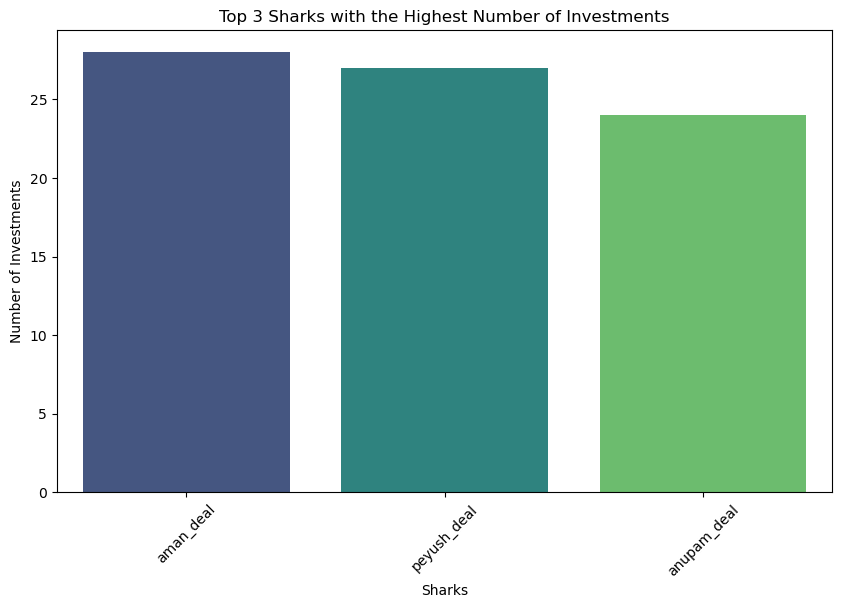

In [65]:
#Top 3 Sharks with the highest number of investments with visualization
shark_name = [col for col in df.columns if col.endswith('_deal')]
shark_number_of_investments = df[shark_name].sum().sort_values(ascending=False)
top_3_sharks = shark_number_of_investments.head(3)
print("Top 3 Sharks with the highest number of investments:")
print(top_3_sharks)
plt.figure(figsize=(10, 6))
sns.barplot(x=top_3_sharks.index, y=top_3_sharks.values, palette='viridis')
plt.title('Top 3 Sharks with the Highest Number of Investments')
plt.xlabel('Sharks')
plt.ylabel('Number of Investments')
plt.xticks(rotation=45)
plt.show()

In [28]:
#Total investments made by all the sharks in the entire season
total_investments = df['deal_amount'].sum()
print(f"Total investments made by all the sharks: {total_investments:.2f}")

Total investments made by all the sharks: 3742.00


In [29]:
#Checking the distribution of deal_equity and is there any outlier present in the column deal_equity for successful deals i.e. deal = 1
deal_data = df[df['deal']==1]['deal_equity']
deal_data.describe()

count    65.000000
mean     16.134308
std      13.923397
min       1.000000
25%       6.000000
50%      15.000000
75%      21.000000
max      75.000000
Name: deal_equity, dtype: float64

Since the mean is greater than the median so it shows the distribution is right skewed

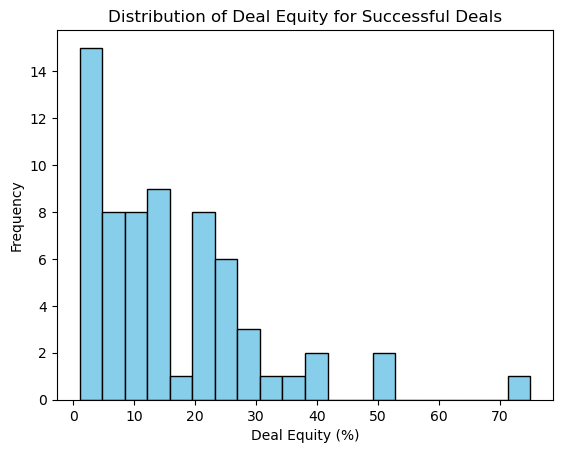

In [30]:
#visualizing the distribution of deal_equity for successful deals using histogram
deal_data.plot(kind='hist', bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Deal Equity for Successful Deals')
plt.xlabel('Deal Equity (%)')
plt.ylabel('Frequency')
plt.show()

In [31]:
#Checking for outliers in the column deal_equity for successful deals using IQR method
Q1 = deal_data.quantile(0.25)
Q3 = deal_data.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = deal_data[(deal_data < lower_bound) | (deal_data > upper_bound)]
print(f"Number of outliers in deal_equity for successful deals: {outliers.count()}")

Number of outliers in deal_equity for successful deals: 3


In [ ]:
#Showing the outliers in the column deal_equity for successful deals
print("Outliers in deal_equity for successful deals:")
print(outliers)

Outliers in deal_equity for successful deals:
1     50.0
66    75.0
82    50.0
Name: deal_equity, dtype: float64


Yes there is outliers present in the deal_equity

The correlation between ask_valuation and deal_valuation for successful deals is: 0.66


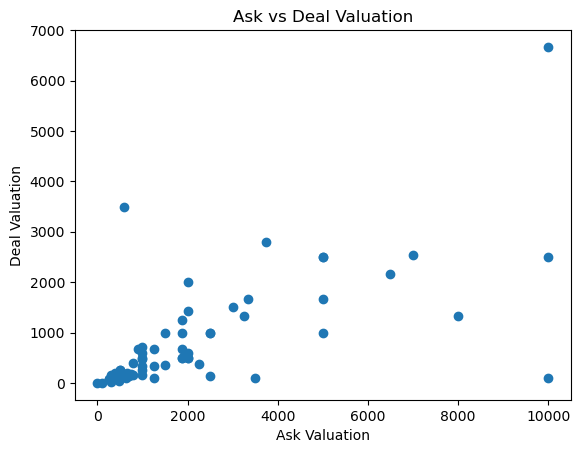

In [33]:
#Checking the correlation between deal_valuation and ask_valuation for successful deals using correlation matrix and scatter plot
valuation_data = df[df['deal'] == 1]
correlation = valuation_data['ask_valuation'].corr(valuation_data['deal_valuation'])
print(f'The correlation between ask_valuation and deal_valuation for successful deals is: {correlation:.2f}')
plt.scatter(valuation_data['ask_valuation'],valuation_data['deal_valuation'])
plt.xlabel("Ask Valuation")
plt.ylabel("Deal Valuation")
plt.title("Ask vs Deal Valuation")
plt.show()

There is a moderate positive correlation between ask_valuation and deal_valuation of 0.66

In [34]:
#Average of equity percentage given to the sharks in successful deals
average_equity_percentage = df[df['deal'] == 1]['deal_equity'].mean()
print(f"Average equity percentage given to the sharks in successful deals: {average_equity_percentage:.2f}%")

Average equity percentage given to the sharks in successful deals: 16.13%


This 16.13% is a decent amount
- This means sharks took the minority of stakes
- Founders retain majority of ownership
- Deals are balanced not aggressive

Episode with the highest number of successful deals: 
episode_number
1     3
8     3
10    3
16    3
17    3
15    3
13    3
33    3
21    3
Name: count, dtype: int64


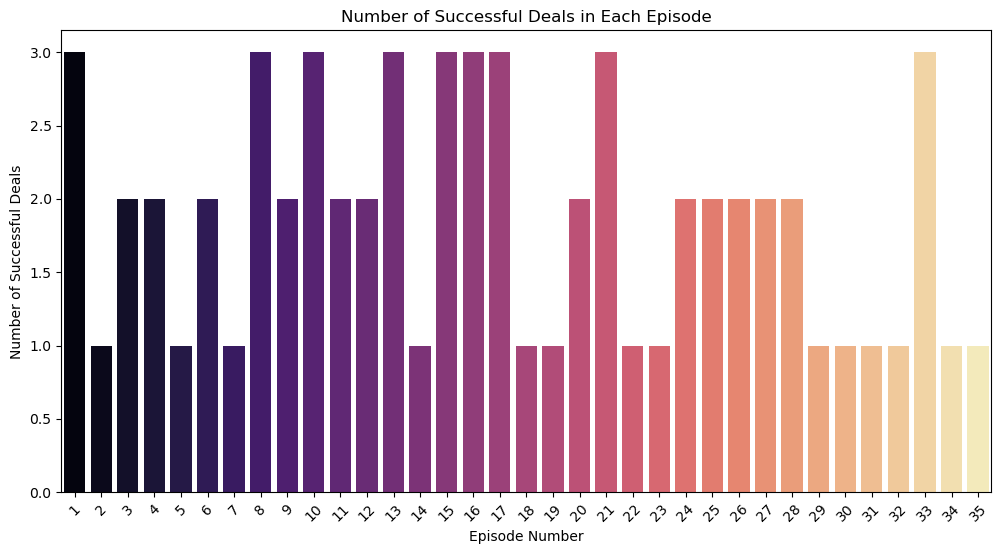

In [35]:
#Episode with the highest numbers of successful deals and visualizing the number of successful deals in each episode using bar plot
episode_successful_deals = df[df['deal'] == 1]['episode_number'].value_counts()
max_number_successful_deals_episode = episode_successful_deals.max()
max_successful_deals_episode = episode_successful_deals[episode_successful_deals == max_number_successful_deals_episode]
print(f"Episode with the highest number of successful deals: \n{max_successful_deals_episode}")
plt.figure(figsize=(12, 6))
sns.barplot(x=episode_successful_deals.index, y=episode_successful_deals.values, palette='magma')
plt.title('Number of Successful Deals in Each Episode')
plt.xlabel('Episode Number')
plt.ylabel('Number of Successful Deals')
plt.xticks(rotation=45)
plt.show()

In [36]:
#Pitches with deal_amount greater than 1 crore and how many of them were successfully recieved investments
high_value_pitches = df[df['pitcher_ask_amount'] > 100]
total_high_value_pitches = high_value_pitches.shape[0]
successful_high_value_pitches = high_value_pitches[high_value_pitches['deal'] == 1].shape[0]
print(f"Total pitches with deal amount greater than 1 crore: {total_high_value_pitches}")
print(f"Number of successful pitches with deal amount greater than 1 crore: {successful_high_value_pitches}")

Total pitches with deal amount greater than 1 crore: 7
Number of successful pitches with deal amount greater than 1 crore: 1


In [37]:
#Percentage of successful deals with more than 1 shark invested
successful_deals_more_than_1_shark = df[(df['deal'] == 1) & (df['total_sharks_invested'] > 1)].shape[0]
total_successful_deals = df[df['deal'] == 1].shape[0]
percentage_successful_deals_more_than_1_shark = (successful_deals_more_than_1_shark / total_successful_deals * 100)
print(f"Percentage of successful deals with more than 1 shark invested: {percentage_successful_deals_more_than_1_shark:.2f}%")

Percentage of successful deals with more than 1 shark invested: 66.15%


66.15% is high which means sharks were believing for contribution in groups more than going alone for reducing the risk factor

Ashneer Grover made 21 investments with a total amount of 494.33
Peyush Bansal made 27 investments with a total amount of 719.67


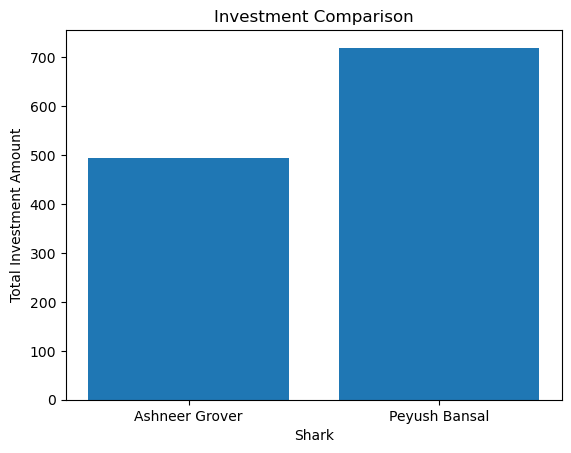

In [38]:
#Investment behaviour of Ashneer Grover and Peyush Bansal in terms of total amount invested
ashneer_deals = df['ashneer_deal'].sum()
peyush_deals = df['peyush_deal'].sum()
ashneer_investment = df[df['ashneer_deal'] == 1]['amount_per_shark'].sum()
peyush_investment = df[df['peyush_deal'] == 1]['amount_per_shark'].sum()
print(f"Ashneer Grover made {ashneer_deals} investments with a total amount of {ashneer_investment:.2f}")
print(f"Peyush Bansal made {peyush_deals} investments with a total amount of {peyush_investment:.2f}")
names = ['Ashneer Grover', 'Peyush Bansal']
totals = [ashneer_investment, peyush_investment]
plt.bar(names, totals)
plt.xlabel("Shark")
plt.ylabel("Total Investment Amount")
plt.title("Investment Comparison")
plt.show()


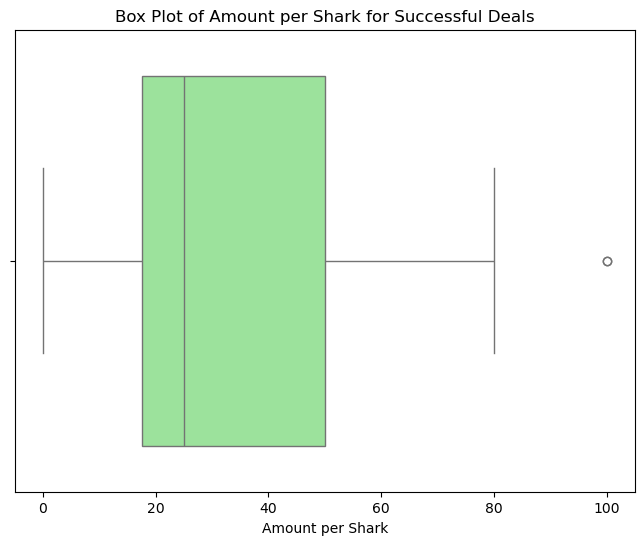

In [39]:
#Box plot to analyze amount_per_shark for successful deals
plt.figure(figsize=(8, 6))
sns.boxplot(x=df[df['deal'] == 1]['amount_per_shark'], color='lightgreen')
plt.title('Box Plot of Amount per Shark for Successful Deals')
plt.xlabel('Amount per Shark')
plt.show()

In [44]:
#checking the summary statistics of amount_per_shark for successful deals
df[df['deal']==1]['amount_per_shark'].describe()

count     65.000000
mean      32.638466
std       22.971095
min        0.000017
25%       17.500000
50%       25.000000
75%       50.000000
max      100.000000
Name: amount_per_shark, dtype: float64

The box plot shows:
- slightly right skew
- Most investment are moderate
- 50% of deals are in range of 18 to 50 approximately
- Lower whishker closer to zero whereas upper whishker closer to 80
- One outlier is also present at around 100

In [66]:
#Is there any case where the deal_amount is greater than the pitcher_ask_amount
greater_deals = df[df['deal_amount'] > df['pitcher_ask_amount']]
print(f"Number of deals where deal_amount > pitcher_ask_amount: {len(greater_deals)}")
if len(greater_deals) > 0:
    print("Examples of such deals:")
    print(greater_deals[['brand_name','idea','pitcher_ask_amount', 'ask_equity', 'ask_valuation', 'deal_amount', 'deal_equity', 'deal_valuation']])

Number of deals where deal_amount > pitcher_ask_amount: 10
Examples of such deals:
              brand_name                            idea  pitcher_ask_amount  \
0    BluePine Industries                    Frozen Momos                50.0   
16           Skippi Pops                        Ice-Pops                45.0   
37                 Annie         Braille Literary Device                30.0   
39       The Yarn Bazaar                Yarn-Trading App                50.0   
43      Hammer Lifestyle            Smart Audio Products                30.0   
59               WeSTOCK  Livestock health monitoring AI                50.0   
64              IN A CAN                   Can Cocktails                50.0   
76          The Sass Bar                           Gifts                40.0   
90              Humpy A2           Organic Milk Products                75.0   
110           Tweek Labs                      Sportswear                40.0   

     ask_equity  ask_valuation  deal

But here is a catch even the deal_amount is greater than the pitcher_ask_amount but most of the time deal_equity is also increasing and the valuation is decreasing

In [67]:
#shark that has the highest return on investment (ROI) based on deal_amount vs. deal_equity
deals_df = df[df['deal'] == 1].copy()
deals_df['ROI'] = deals_df['deal_equity'] / deals_df['deal_amount']
roi_dict = {
    'Ashneer': deals_df[deals_df['ashneer_deal'] == 1]['ROI'].mean(),
    'Anupam': deals_df[deals_df['anupam_deal'] == 1]['ROI'].mean(),
    'Aman': deals_df[deals_df['aman_deal'] == 1]['ROI'].mean(),
    'Namita': deals_df[deals_df['namita_deal'] == 1]['ROI'].mean(),
    'Vineeta': deals_df[deals_df['vineeta_deal'] == 1]['ROI'].mean(),
    'Peyush': deals_df[deals_df['peyush_deal'] == 1]['ROI'].mean(),
    'Ghazal': deals_df[deals_df['ghazal_deal'] == 1]['ROI'].mean()
}

roi_result = pd.Series(roi_dict).sort_values(ascending=False)
print(f"Shark that has the highest ROI is {roi_result.index[0]} with an average ROI of {roi_result.values[0]:.2f}")

Shark that has the highest ROI is Namita with an average ROI of 4725.71


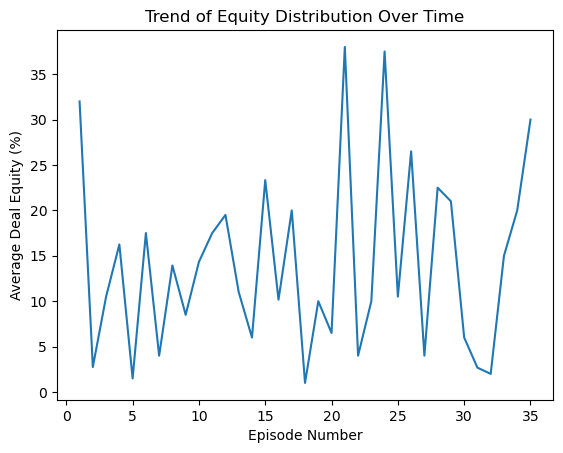

In [ ]:
#Identify trends in equity distribution — is sharks investing in lower or higher equity stakes over time
deals_df = df[df['deal'] == 1].copy()
equity_trend = deals_df.groupby('episode_number')['deal_equity'].mean()
plt.figure()
plt.plot(equity_trend.index, equity_trend.values)
plt.xlabel("Episode Number")
plt.ylabel("Average Deal Equity (%)")
plt.title("Trend of Equity Distribution Over Time")
plt.show()

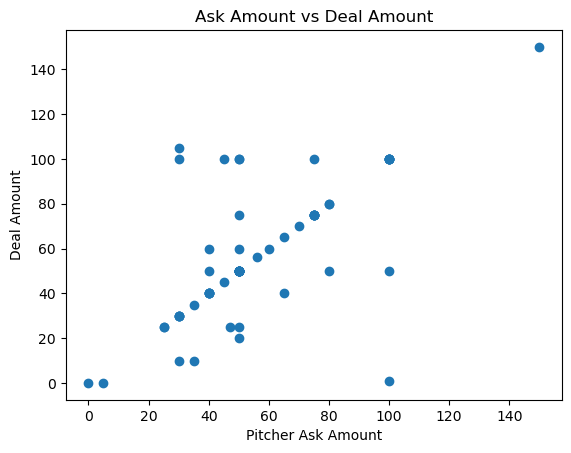

Pitchers asking less are more likely to secure deals.


In [58]:
#Checking the correlation between pitcher_ask_amount and deal_amount for successful deals and pitchers who ask for less tend to secure more deals
deals_df = df[df['deal'] == 1].copy()
deals_df[['pitcher_ask_amount', 'deal_amount']].corr()

plt.figure()
plt.scatter(deals_df['pitcher_ask_amount'], deals_df['deal_amount'])
plt.xlabel("Pitcher Ask Amount")
plt.ylabel("Deal Amount")
plt.title("Ask Amount vs Deal Amount")
plt.show()

success_avg = df[df['deal'] == 1]['pitcher_ask_amount'].mean()
failure_avg = df[df['deal'] == 0]['pitcher_ask_amount'].mean()

success_avg, failure_avg
if success_avg < failure_avg:
    print("Pitchers asking less are more likely to secure deals.")
elif success_avg == failure_avg:
    print("Ask amount not major factor.")
else:
    print("Higher ask startups still secure deals (maybe stronger businesses)")

Higher pitcher_ask_amount lead to higher deal_amount and pitchers asking less are more likely to secure deals

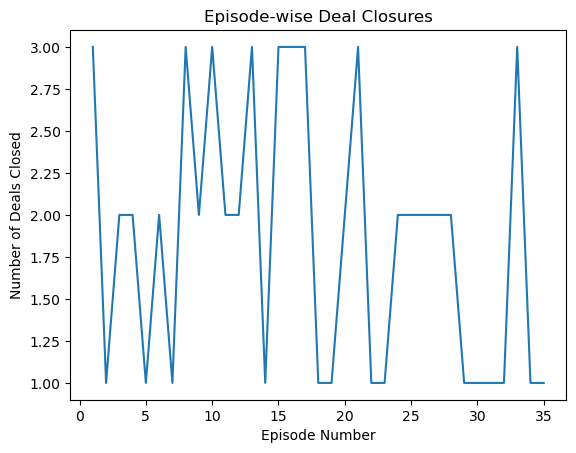

In [60]:
#Identify if there is a pattern in episode-wise deal closures—do certain episodes see more investments
episode_deals = df.groupby('episode_number')['deal'].sum()

plt.figure()
plt.plot(episode_deals.index, episode_deals.values)
plt.xlabel("Episode Number")
plt.ylabel("Number of Deals Closed")
plt.title("Episode-wise Deal Closures")
plt.show()

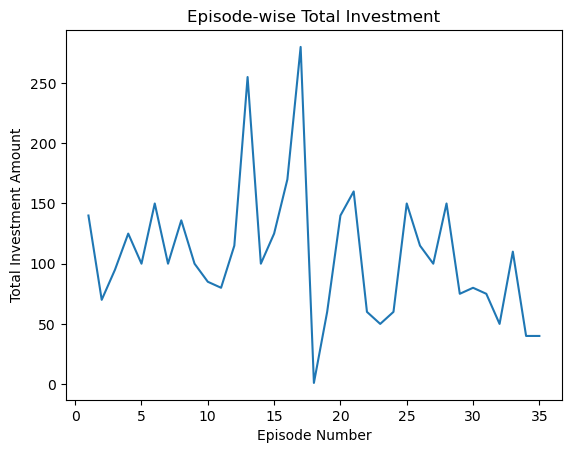

In [ ]:
deals_df = df[df['deal'] == 1].copy()
episode_investment = deals_df.groupby('episode_number')['deal_amount'].sum()

plt.figure()
plt.plot(episode_investment.index, episode_investment.values)
plt.xlabel("Episode Number")
plt.ylabel("Total Investment Amount")
plt.title("Episode-wise Total Investment")
plt.show()

                deal_equity  deal_valuation
deal_equity         1.00000        -0.51675
deal_valuation     -0.51675         1.00000


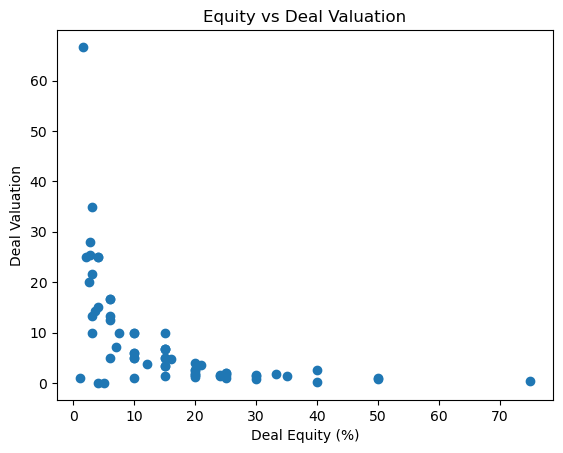

In [72]:
#Analyze the impact of equity dilution on deal_valuation. Are lower equity asks leading to higher deal valuations
deals_df = df[df['deal'] == 1].copy()
deals_df['deal_valuation'] = deals_df['deal_amount'] / deals_df['deal_equity']

print(deals_df[['deal_equity', 'deal_valuation']].corr())

plt.figure()
plt.scatter(deals_df['deal_equity'], deals_df['deal_valuation'])
plt.xlabel("Deal Equity (%)")
plt.ylabel("Deal Valuation")
plt.title("Equity vs Deal Valuation")
plt.show()

There is a moderate negative correlation between equity dilution and deal valuation